In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

## **Data loading** ##

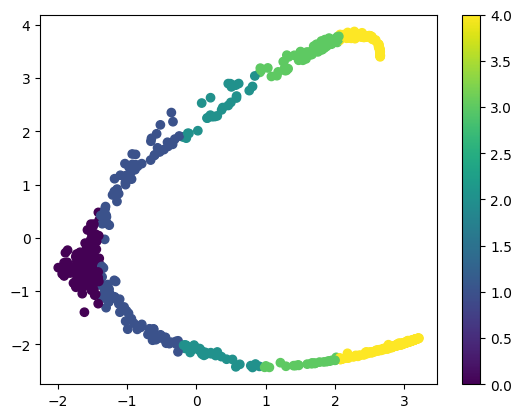

In [2]:
# data_name = 'simulation'
# nu = 0.1
# delta = 2

# data_name = 'mouse'
# nu = 2
# delta = 15

data_name = 'Dygen'
nu = 0.1
delta = 1.7
legend_loc = 'upper left'

# data = pd.read_csv('data/simulation_gene_data.csv')
# data = pd.read_csv('data/Weinreb_alltime.csv')
data = pd.read_csv('data/dygen.csv')

t = np.array(data)[:,0]
X = np.array(data)[:,1:]
X1 = X[:,0]
X2 = X[:,1]
plt.scatter(X1,X2,c=t)
plt.colorbar()

## **Branching plot** ##

In [3]:
from utils import SDE, plot_branching_phase_portrait, plot_branching_phase_portrait2
Xs = [] 
max_sample_time = int(np.max(data['samples']))
for k in range(max_sample_time + 1): 
    Xs.append(np.array(data[data['samples'] == k])[:, 1:]) 

model = torch.load(f'{data_name}_{delta}_{nu}.pth', weights_only=False, map_location=torch.device('cpu'))
model.eval()
simulator = SDE(model, nu, mode = 3, positive=False) 
        
# Simulation use X0[170,399]
# Dygen use X0[12,133,12,14,148,100,10,2,127]
# x_source = torch.tensor(Xs[0][np.array([0,1,2,3,4,5,6,7,8,9,10]),:], dtype=torch.float32, device = 'cpu') 



# 1. 仅使用原始的 Xs[0] 作为起点 (不需要再做 .tolist()*50 的重复扩展了)
x_source = torch.tensor(Xs[0], dtype=torch.float32, device='cpu') 

# 2. 准备一个总列表，用来收集 100 次独立模拟的所有轨迹
all_genealogies = []

num_runs = 100
print(f"开始执行 {num_runs} 次独立分支模拟...")

simulated_final_cells = []  # 用于收集每次模拟中存活到最后的细胞位置

for i in range(num_runs):
    # 打印进度，防止干等
    print(i)
        
    # 每次从相同的初始状态集合出发，生成一批独立的随机轨迹
    genealogy, ms, action = simulator.trajectory(
        x=x_source, 
        m=torch.zeros([x_source.size(0), 1], device='cpu'), 
        delta=delta, 
        T=max_sample_time, 
        N=max_sample_time * 100
    )
    
    # 遍历所有模拟出的细胞轨迹 (genealogy)
    for k in range(len(genealogy)):
        # 提取轨迹的时间序列
        t_array = genealogy[k]['t']
        
        # 提取最后时刻的时间戳，判断该细胞是否存活到了最后
        # 考虑到浮点数累加的微小精度误差，减去一个 1e-3 的容差
        if t_array[-1] >= max_sample_time - 1e-3:
            last_pos = genealogy[k]['x'][-1]
            
            # 兼容处理：如果是 PyTorch Tensor，转换为 NumPy array
            if torch.is_tensor(last_pos):
                last_pos = last_pos.detach().cpu().numpy()
            elif not isinstance(last_pos, np.ndarray):
                last_pos = np.array(last_pos)
                
            simulated_final_cells.append(last_pos)

simulated_final_cells = np.array(simulated_final_cells)

d:\program files\lib\site-packages\ot\backend.py:2998: UserWarning: To use TensorflowBackend, you need to activate the tensorflow numpy API. You can activate it by running: 
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
  register_backend(TensorflowBackend())


开始执行 100 次独立分支模拟...
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


d:\program files\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Ground Truth 比例 -> 分支 0: 0.708, 分支 1: 0.292
USB 预测比例 -> 分支 0: 0.650, 分支 1: 0.350


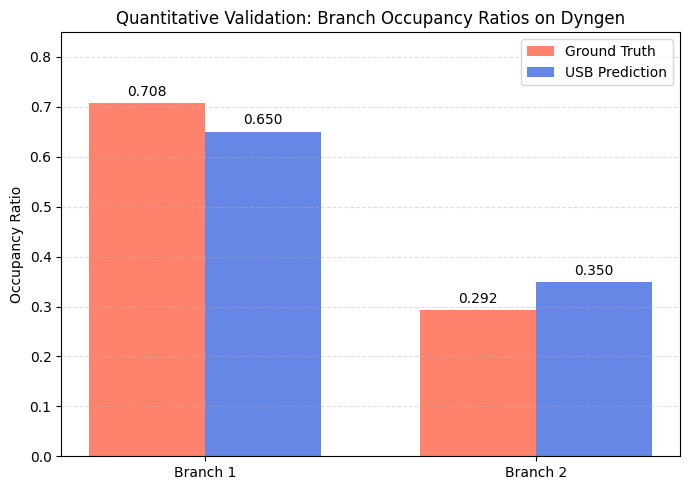

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ==========================================
# 1. 真实数据的分支比例统计 (Ground Truth)
# ==========================================
# 取出真实数据的最后一个时间点
true_final_cells = Xs[-1]  

# 使用 KMeans 将真实的终点细胞聚成两类 (自动寻找上下分支)
kmeans = KMeans(n_clusters=2, random_state=42).fit(true_final_cells)
true_labels = kmeans.labels_

count_true_0 = np.sum(true_labels == 0)
count_true_1 = np.sum(true_labels == 1)
total_true = count_true_0 + count_true_1

ratio_true_0 = count_true_0 / total_true
ratio_true_1 = count_true_1 / total_true

print(f"Ground Truth 比例 -> 分支 0: {ratio_true_0:.3f}, 分支 1: {ratio_true_1:.3f}")

# ==========================================
# 2. 提取 USB 模拟结果并进行分支判定
# ==========================================


if len(simulated_final_cells) == 0:
    print("警告：没有细胞存活到最后时刻！请检查模拟器参数或是否有过于极端的凋亡率。")
else:
    # 🌟 修复 dtype 不匹配的报错：强制转换数据类型
    simulated_final_cells = simulated_final_cells.astype(true_final_cells.dtype)
    
    # 使用 Ground Truth 训好的 KMeans 分类器，预测模拟细胞的归属
    sim_labels = kmeans.predict(simulated_final_cells)
    
    count_sim_0 = np.sum(sim_labels == 0)
    count_sim_1 = np.sum(sim_labels == 1)
    total_sim = count_sim_0 + count_sim_1
    
    ratio_sim_0 = count_sim_0 / total_sim
    ratio_sim_1 = count_sim_1 / total_sim
    
    print(f"USB 预测比例 -> 分支 0: {ratio_sim_0:.3f}, 分支 1: {ratio_sim_1:.3f}")

    # ==========================================
    # 3. 可视化对比柱状图 (Branch Occupancy Ratios)
    # ==========================================
    labels = ['Branch 1', 'Branch 2']
    true_ratios = [ratio_true_0, ratio_true_1]
    sim_ratios = [ratio_sim_0, ratio_sim_1]
    
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(7, 5))
    rects1 = ax.bar(x - width/2, true_ratios, width, label='Ground Truth', color='tomato', alpha=0.8)
    rects2 = ax.bar(x + width/2, sim_ratios, width, label='USB Prediction', color='royalblue', alpha=0.8)
    
    ax.set_ylabel('Occupancy Ratio')
    ax.set_title('Quantitative Validation: Branch Occupancy Ratios on Dyngen')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    # 在柱子上打上具体的数值标签
    ax.bar_label(rects1, fmt='%.3f', padding=3)
    ax.bar_label(rects2, fmt='%.3f', padding=3)
    
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    # 留出 20% 的顶部空间防止标签被挡住
    plt.ylim(0, max(max(true_ratios), max(sim_ratios)) * 1.2) 
    plt.tight_layout()
    plt.savefig(f'{data_name}_division_event_validation.png', dpi=300)
    plt.show()